# MLR (Multiple Linear Regression)

In [143]:
#Loading required packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
pd.set_option('display.max_columns',200)
import warnings
warnings.filterwarnings('ignore')

In [144]:
#Loading Dataset
df=pd.read_csv('C:/Data Science/Assignments_Files/MLR/ToyotaCorolla - MLR.csv')
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [145]:
#Creating copy of dataset for backup
df_copy=df.copy()

### 1.Perform exploratory data analysis (EDA) to gain insights into the dataset.

In [147]:
# Checking for rows and columns
df.shape

(1436, 11)

In [148]:
#Checking column names
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [149]:
# Checking datatype and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [150]:
# Stastical Information
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [151]:
# Checking for null values
df.isna().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [152]:
# Checking for duplicates
df.duplicated().sum()

1

In [153]:
df[df.duplicated()]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


In [154]:
# Removing Duplicates
df.drop_duplicates(inplace=True)

In [155]:
## Checking for outliers
def check_outlier(df):

    cols = df.select_dtypes(include=["int", "float"]).columns
    col_with_outliers = []

    for col in cols:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        IQR = q3 - q1

        lower = q1 - 1.5 * IQR
        upper = q3 + 1.5 * IQR

        if df[(df[col] < lower) | (df[col] > upper)].shape[0] > 0:
            col_with_outliers.append(col)

    return col_with_outliers  

In [156]:
print("Columns with outliers: ",check_outlier(df))

Columns with outliers:  ['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Gears', 'Weight']


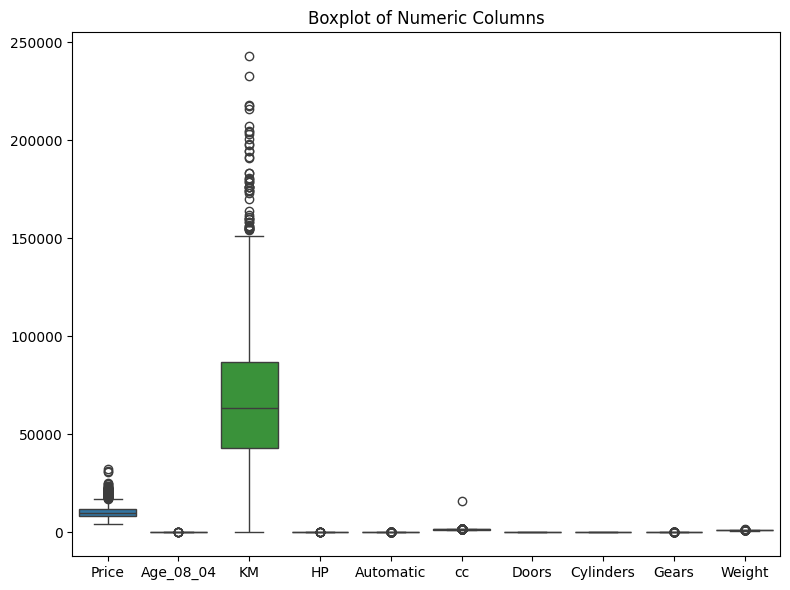

In [157]:
# Verifying with boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=df)
plt.title("Boxplot of Numeric Columns")
plt.tight_layout()
plt.show()

Outliers were identified using the IQR method and boxplots. Since extreme values can significantly affect the regression model, 
outliers need to be removed to improve model performance and obtain more reliable predictions.

In [159]:
# Removing outliers
def remove_outliers(df):

    cols = df.select_dtypes(include=["int64","float64"]).columns

    for col in cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

<Axes: >

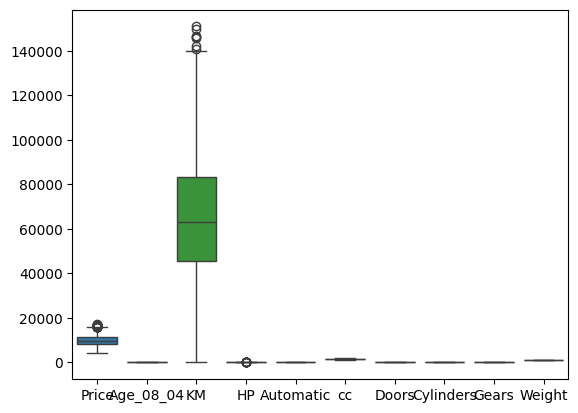

In [160]:
df = remove_outliers(df)
#Checking if outliers were removed or not
sns.boxplot(data=df)

Outliers were detected using the Interquartile Range (IQR) method. Extreme values in the Price variable were treated to reduce their influence on the regression model and improve prediction accuracy.

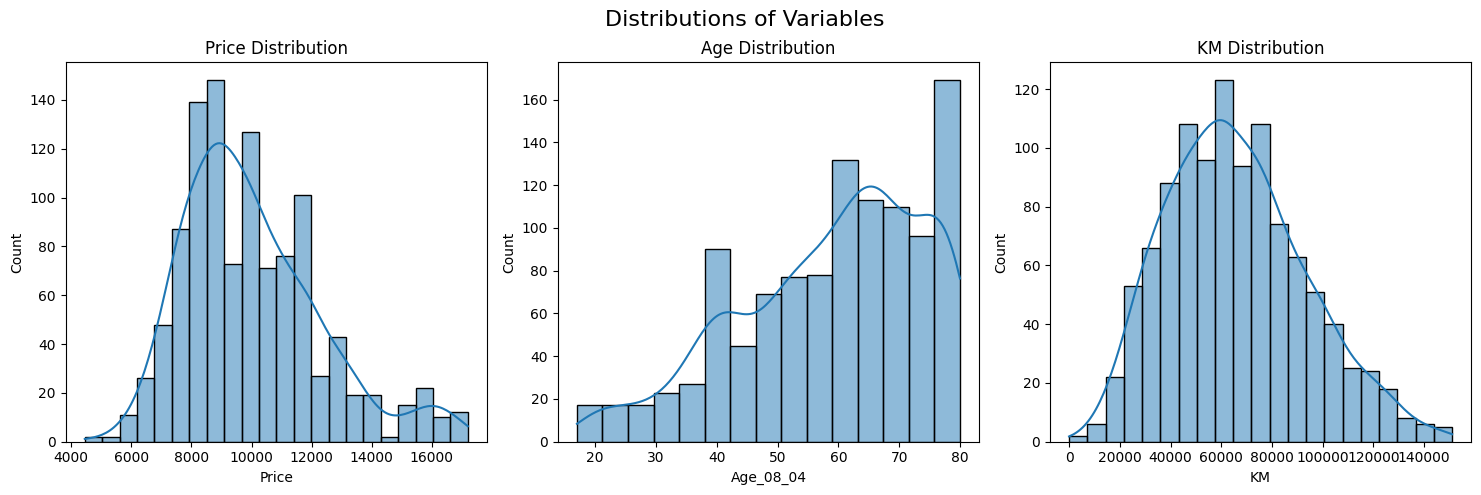

In [162]:
# Checking Distributions for variables
plt.figure(figsize=(15,5))

# 1. Price Distribution
plt.subplot(1,3,1)
sns.histplot(df["Price"],kde=True)
plt.title("Price Distribution")

# 2. Age Distribution
plt.subplot(1,3,2)
sns.histplot(df["Age_08_04"],kde=True)
plt.title("Age Distribution")

# 3. KM Distribution
plt.subplot(1,3,3)
sns.histplot(df["KM"],kde=True)
plt.title("KM Distribution")

plt.tight_layout(rect=[0,0,1,0.95])
plt.suptitle("Distributions of Variables",fontsize=16)
plt.show()

#### Insights from the Distributions
1. Price Distribution

- The price distribution is slightly right-skewed.

- Most Toyota Corolla cars are priced between €8000 and €11000.

2. Age Distribution

- The age distribution is slightly left-skewed, with more cars clustered between 60–80 months.

- Fewer cars exist in the very new category (below 30 months).

3. KM (Mileage) Distribution

- The KM distribution is approximately normal (bell-shaped).

- Most cars have mileage between 40,000 km and 80,000 km.

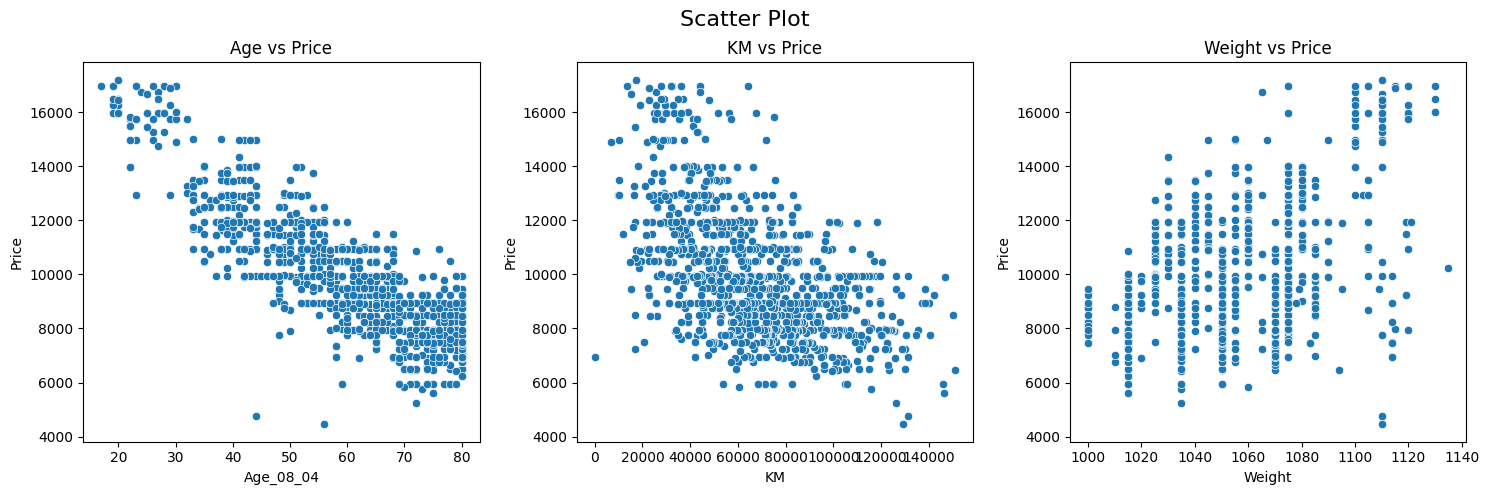

In [164]:
# Plotting Scatter plots
plt.figure(figsize=(15,5))

# 1. Age vs Price
plt.subplot(1,3,1)
sns.scatterplot(x="Age_08_04", y="Price", data=df)
plt.title("Age vs Price")

# 2. KM vs Price
plt.subplot(1,3,2)
sns.scatterplot(x="KM", y="Price", data=df)
plt.title("KM vs Price")

# 3. Weight vs Price
plt.subplot(1,3,3)
sns.scatterplot(x="Weight", y="Price", data=df)
plt.title("Weight vs Price")

plt.tight_layout(rect=[0,0,1,0.95])
plt.suptitle("Scatter Plot",fontsize=16)
plt.show()

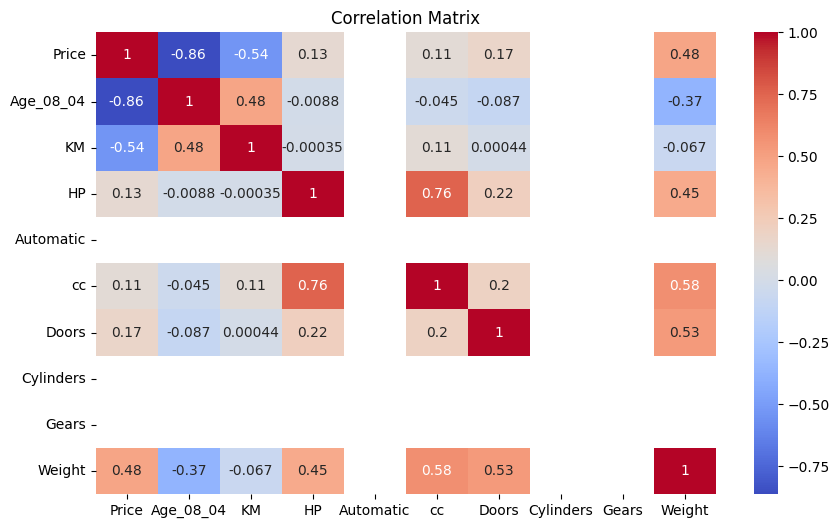

In [165]:
# Correlation Analysis
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=["int64","float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [166]:
df = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)

In [167]:
# Define Features and Target
X = df.drop("Price", axis=1)
y = df["Price"]

### 2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [169]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 3.Build a multiple linear regression model using the training dataset. 

In [171]:
# importing Linear Regression
from sklearn.linear_model import LinearRegression

In [172]:
# Model 1 (Using Age and KM)
model1 = LinearRegression()

X_train_m1 = X_train[["Age_08_04","KM"]]

model1.fit(X_train_m1, y_train)

print("Intercept:", model1.intercept_)
print("Coefficients:", model1.coef_)

Intercept: 17876.389817102077
Coefficients: [-1.20788306e+02 -1.19308226e-02]


In [173]:
# Model 2 (Add HP and Weight)
model2 = LinearRegression()

X_train_m2 = X_train[["Age_08_04","KM","HP","Weight"]]

model2.fit(X_train_m2, y_train)

print("Intercept:", model2.intercept_)
print("Coefficients:", model2.coef_)

Intercept: 1549.924253761892
Coefficients: [-1.09433654e+02 -1.42743861e-02  1.10403654e+01  1.39015377e+01]


In [174]:
# Model 3 (Full Model)
model3 = LinearRegression()

model3.fit(X_train, y_train)

print("Intercept:", model3.intercept_)
print("Coefficients:", model3.coef_)

Intercept: -6743.511666153019
Coefficients: [-1.14961275e+02 -1.20233574e-02 -1.58989207e+02  2.13340456e-12
  1.18883056e+01 -7.83676190e+01  1.81898940e-12 -1.81898940e-12
  2.11429578e+01 -1.16749024e+04  7.85565354e+02]


In [175]:
#Create a table of coefficients:
coeff = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model3.coef_
})

print(coeff)

             Feature   Coefficient
0          Age_08_04 -1.149613e+02
1                 KM -1.202336e-02
2                 HP -1.589892e+02
3          Automatic  2.133405e-12
4                 cc  1.188831e+01
5              Doors -7.836762e+01
6          Cylinders  1.818989e-12
7              Gears -1.818989e-12
8             Weight  2.114296e+01
9   Fuel_Type_Diesel -1.167490e+04
10  Fuel_Type_Petrol  7.855654e+02


#### 4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset

In [177]:
# Make Predictions on Test Data
y_pred = model3.predict(X_test)

In [178]:
# Import Evaluation Metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

In [179]:
# Calculating metrics
r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

R2 Score: 0.8034370721931834
MSE: 1102448.2185110357
RMSE: 1049.975341858577
MAE: 810.337868212614


#### 5.Apply Lasso and Ridge methods on the model.

In [181]:
# Import Libraries
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [182]:
# Ridge Regression Model
ridge = Ridge(alpha=1)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [183]:
# Evaluate Ridge Model
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge R2:", ridge_r2)
print("Ridge RMSE:", ridge_rmse)

Ridge R2: 0.7987337799538641
Ridge RMSE: 1062.4628144711426


In [184]:
# Evaluate Ridge Model
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge R2:", ridge_r2)
print("Ridge RMSE:", ridge_rmse)

Ridge R2: 0.7987337799538641
Ridge RMSE: 1062.4628144711426


In [185]:
# Evaluate Lasso Model
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [186]:
y_pred_lasso = lasso.predict(X_test)

In [187]:
# Evaluate the Model
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lasso_r2 = r2_score(y_test, y_pred_lasso)

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso R2:", lasso_r2)
print("Lasso RMSE:", lasso_rmse)

Lasso R2: 0.8033574101352025
Lasso RMSE: 1050.1880847307598


In [188]:
# Check Coefficients
ridge_coeff = pd.Series(ridge.coef_, index=X_train.columns)
lasso_coeff = pd.Series(lasso.coef_, index=X_train.columns)

print("Ridge Coefficients")
print(ridge_coeff)

print("Lasso Coefficients")
print(lasso_coeff)

Ridge Coefficients
Age_08_04           -110.485474
KM                    -0.011873
HP                    -6.932520
Automatic              0.000000
cc                     0.287598
Doors                -54.354225
Cylinders              0.000000
Gears                  0.000000
Weight                19.774253
Fuel_Type_Diesel   -1844.482152
Fuel_Type_Petrol     790.337170
dtype: float64
Lasso Coefficients
Age_08_04            -114.741086
KM                     -0.012022
HP                   -151.560034
Automatic               0.000000
cc                     11.322182
Doors                 -76.970528
Cylinders               0.000000
Gears                   0.000000
Weight                 21.065898
Fuel_Type_Diesel   -11199.351432
Fuel_Type_Petrol      780.875874
dtype: float64


### Ridge Regression Interpretation

- Ridge regression slightly reduces the magnitude of the coefficients compared to the ordinary linear regression model.
- Important variables influencing the price include **Age_08_04, KM, HP, and Weight**.
- **Age_08_04 and KM have negative coefficients**, indicating that as the age of the car and mileage increase, the price decreases.
- **Weight and engine capacity (cc) have positive coefficients**, meaning heavier cars with larger engines tend to have higher prices.
- Variables such as **Automatic, Cylinders, and Gears have coefficients close to zero**, indicating minimal influence on the price.

### Lasso Regression Interpretation

- Lasso regression shrinks the coefficients and can reduce some of them to **exactly zero**.
- This helps in **automatic feature selection**, identifying the most important predictors.
- In this model, variables like **Automatic, Cylinders, and Gears have coefficients equal to zero**, indicating they do not significantly affect the car price.
- The most influential variables remain **Age_08_04, KM, HP, cc, Doors, Weight, and Fuel_Type_Petrol**.

### Key Observation

- Both Ridge and Lasso produce **similar coefficient values**, suggesting that multicollinearity is not severe in the dataset.
- **Age and KM negatively impact the car price**, while **Weight and engine capacity positively impact the price**.

### Conclusion

- Regularization techniques such as **Ridge and Lasso regression** were applied to improve the model.
- Ridge regression reduces the magnitude of coefficients while retaining all variables.
- Lasso regression performs **feature selection by shrinking less important coefficients to zero**.
- Important predictors influencing the Toyota Corolla price include **Age, KM, HP, cc, Doors, and Weight**.

### Interview Questions
#### 1. What is Normalization & Standardization? How are they helpful?

**Answer:**

Normalization and Standardization are **feature scaling techniques** used to bring all input variables to a comparable scale.

- **Normalization** rescales data to a fixed range, usually **[0, 1]**, using Min-Max scaling.  
- **Standardization** transforms data so that it has a **mean of 0 and standard deviation of 1** using Z-score.

**When to use:**
- Normalization → when data has bounded range (e.g., image pixels, neural networks)  
- Standardization → when data follows normal distribution or in regression models  

**Why they are helpful:**
- Prevents features with large values from dominating the model  
- Improves convergence speed of algorithms (especially gradient descent)  
- Essential for distance-based algorithms like KNN, K-Means  
- Leads to better and more stable model performance  

---

#### 2. What techniques can be used to address multicollinearity in multiple linear regression?

**Answer:**

Multicollinearity occurs when **independent variables are highly correlated**, leading to unstable coefficients and poor interpretability.

**Techniques to handle it:**

1. **Remove correlated features**  
   - Use correlation matrix and drop one of the highly correlated variables  

2. **Variance Inflation Factor (VIF)**  
   - Identify problematic variables (VIF > 5 or 10) and remove them  

3. **Feature Selection methods**  
   - Forward selection / Backward elimination  

4. **Principal Component Analysis (PCA)**  
   - Transform correlated variables into uncorrelated components  

5. **Regularization techniques**  
   - **Ridge Regression (L2):** reduces coefficient variance  
   - **Lasso Regression (L1):** can eliminate features  

6. **Combine features**  
   - Create a new feature from correlated variables  
